In [1]:

%reload_ext autoreload
%autoreload 2
import os, re
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from neuro_py.raw import preprocessing as prpc 

from pathlib import Path
from src.preprocess import (
    PreprocessConfig,
    prepare_chanmap,
    run_preprocess_session,
    select_paths_with_gui,
    show_chanmap,
)
from src.preprocess.io import copy_results_to_basepath


In [2]:
def extract_datetime(path):
    m = re.search(r'(\d{6}_\d{6})', str(path))
    if m:
        return datetime.strptime(m.group(1), "%y%m%d_%H%M%S")
    return datetime.min 

In [3]:
use_gui = False
manual_basepath = "/local/workdir/ys2375/data/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20"
basePath, basename, local_output_dir, xml_path = select_paths_with_gui(
    use_gui=use_gui,
    manual_basepath=manual_basepath,
    initial_drive=r'S:\\',
    # local_root=Path('/fs/cbsuruizfs1/storage/ys2375/sorting_temp'),
    local_root=Path.cwd() / 'sorting_temp',
)


if basePath:
    print(f"Selected folder: {basePath}")
    dataDirs = sorted([p for p in basePath.iterdir() if p.is_dir()], key=extract_datetime)
    display(dataDirs)
else:
    print("No folder selected")
    basePath = None

Selected folder: /fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20


[PosixPath('/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/psico_presleep_260514_103223'),
 PosixPath('/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/pisco_linear_track_260514_142413'),
 PosixPath('/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/pisco_postsleep_260514_144740'),
 PosixPath('/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/pisco_postsleep_260514_155814')]

In [15]:
dataDir = dataDirs[2]
dat_files = sorted(dataDir.glob('*.dat'))
if not dat_files:
    raise FileNotFoundError(f'No .dat files found in {dataDir}')
dataPath2Cut = dat_files[0]
dataPath2Cut

PosixPath('/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/pisco_postsleep_260514_144740/amplifier.dat')

In [16]:
n_channels_amplifier = 256  # number of channels in amplifier.dat; change if yours differs      
fs = 20_000                     # sampling rate [Hz]; change if yours differs

# --- compute n_samples from amplifier.dat size ---
bytes_per_sample = np.dtype(np.int16).itemsize  # amplifier.dat is int16 -> 2 bytes
n_samples = os.path.getsize(dataPath2Cut) // (n_channels_amplifier * bytes_per_sample)
seconds = n_samples / fs
m, s = divmod(int(seconds), 60)
ms = int((seconds - int(seconds)) * 1000)
print(f"n_samples: {n_samples}, duration: {m} min {s} sec {ms} ms")

n_samples: 77971456, duration: 64 min 58 sec 572 ms


In [17]:
# --- build cut_intervals ---
# NOTE: interval is half-open [start, end)
last_start = max(0, n_samples - int(100 * fs))  # clamp to 0 if shorter than 10s
cut_intervals = [(last_start, n_samples)]
print(f"cut_intervals: {cut_intervals}")
for label, samples in zip(["start", "end"], [last_start, n_samples]):
    secs = samples / fs
    m, s = divmod(int(secs), 60)
    ms = int((secs - int(secs)) * 1000)
    print(f"{label}: {m} min {s} sec {ms} ms")

cut_intervals: [(75971456, 77971456)]
start: 63 min 18 sec 572 ms
end: 64 min 58 sec 572 ms


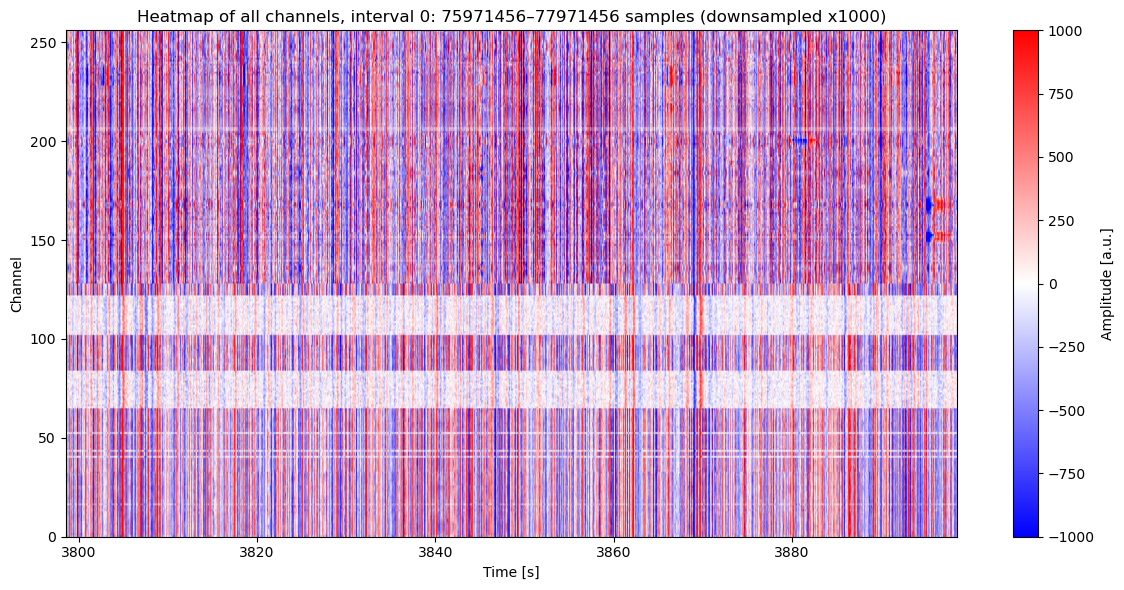

In [18]:
# Load with memory mapping 
data = np.memmap(dataPath2Cut, dtype=np.int16, mode="r")
n_samples = data.size // n_channels_amplifier
data = data.reshape((n_samples, n_channels_amplifier))

# Plot all channels in each cut interval as a heatmap
for i, (start, end) in enumerate(cut_intervals):
    sig = data[start:end, :]     # shape: (samples, channels)
    t = np.arange(start, end) / fs  # time axis in seconds

    # Downsample for faster plotting (every 10th sample)
    downsample_factor = 1000
    sig_downsampled = sig[::downsample_factor, :]
    t_downsampled = t[::downsample_factor]

    plt.figure(figsize=(12, 6))
    # Transpose so that rows=channels, cols=time
    plt.imshow(sig_downsampled.T, aspect="auto", vmin=-1000, vmax=1000,
               extent=[t_downsampled[0], t_downsampled[-1], 0, n_channels_amplifier],
               origin="lower", cmap="bwr")
    plt.colorbar(label="Amplitude [a.u.]")
    plt.xlabel("Time [s]")
    plt.ylabel("Channel")
    plt.title(f"Heatmap of all channels, interval {i}: {start}–{end} samples (downsampled x{downsample_factor})")
    plt.tight_layout()
    plt.show()

In [20]:
# prpc.cut_artifacts_intan(
#     folder_name=str(dataDir),
#     n_channels_amplifier=n_channels_amplifier,
#     cut_intervals=cut_intervals,
# )

## Tail-Trim To `*_trim.dat`

Use this section when the files share the same start time and only the tail is mismatched.
It keeps the original `.dat` files untouched and writes trimmed copies alongside them.

In [ ]:
# from math import lcm
# from pathlib import Path
# import os
# import numpy as np

# FILE_SPECS = {
#     "amplifier": {"dtype": np.int16, "rate_divisor": 1, "fixed_channels": n_channels_amplifier},
#     "time": {"dtype": np.int32, "rate_divisor": 1, "fixed_channels": 1},
#     "digitalin": {"dtype": np.uint16, "rate_divisor": 1, "fixed_channels": 1},
#     "digitalout": {"dtype": np.uint16, "rate_divisor": 1, "fixed_channels": 1},
#     "analogin": {"dtype": np.uint16, "rate_divisor": 1, "fixed_channels": None},
#     "auxiliary": {"dtype": np.uint16, "rate_divisor": 4, "fixed_channels": None},
#     "supply": {"dtype": np.uint16, "rate_divisor": 60, "fixed_channels": None},
# }


# def infer_channel_count(
#     file_size: int,
#     dtype: np.dtype,
#     rate_divisor: int,
#     amp_samples: int,
#     *,
#     fixed_channels: int | None = None,
#     max_channels: int = 512,
#  ) -> int:
#     if fixed_channels is not None:
#         return int(fixed_channels)

#     candidates = []
#     for n_channels in range(1, max_channels + 1):
#         frame_bytes = n_channels * dtype.itemsize
#         if file_size % frame_bytes != 0:
#             continue
#         n_rows = file_size // frame_bytes
#         amp_equiv_samples = n_rows * rate_divisor
#         overshoots = int(amp_equiv_samples > amp_samples)
#         diff = abs(amp_equiv_samples - amp_samples)
#         candidates.append((overshoots, diff, n_channels))

#     if not candidates:
#         raise ValueError(
#             f"Could not infer a valid channel count for file size {file_size} bytes"
#         )

#     candidates.sort(key=lambda item: (item[0], item[1], item[2]))
#     return int(candidates[0][2])


# def inspect_intan_dat_files(folder: Path, amp_samples: int) -> tuple[list[dict], int]:
#     summary = []
#     divisors_present = []

#     for stem, spec in FILE_SPECS.items():
#         path = folder / f"{stem}.dat"
#         if not path.exists():
#             continue

#         dtype = np.dtype(spec["dtype"])
#         rate_divisor = int(spec["rate_divisor"])
#         file_size = path.stat().st_size
#         n_channels = infer_channel_count(
#             file_size,
#             dtype,
#             rate_divisor,
#             amp_samples,
#             fixed_channels=spec["fixed_channels"],
#         )

#         frame_bytes = n_channels * dtype.itemsize
#         if file_size % frame_bytes != 0:
#             raise ValueError(
#                 f"{stem}.dat size {file_size} is not divisible by frame size {frame_bytes}"
#             )

#         n_rows = file_size // frame_bytes
#         amp_equiv_samples = n_rows * rate_divisor
#         divisors_present.append(rate_divisor)
#         summary.append(
#             {
#                 "stem": stem,
#                 "path": path,
#                 "dtype": dtype,
#                 "rate_divisor": rate_divisor,
#                 "n_channels": int(n_channels),
#                 "n_rows": int(n_rows),
#                 "amp_equiv_samples": int(amp_equiv_samples),
#                 "file_size": int(file_size),
#             }
#         )

#     if not summary:
#         raise FileNotFoundError(f"No Intan .dat files found in {folder}")

#     alignment = 1
#     for divisor in divisors_present:
#         alignment = lcm(alignment, int(divisor))

#     target_amp_samples = min(row["amp_equiv_samples"] for row in summary)
#     target_amp_samples = (target_amp_samples // alignment) * alignment
#     if target_amp_samples <= 0:
#         raise ValueError("target_amp_samples resolved to 0")

#     for row in summary:
#         row["target_rows"] = target_amp_samples // row["rate_divisor"]
#         row["trim_rows"] = row["n_rows"] - row["target_rows"]
#         row["trim_seconds"] = row["trim_rows"] / (fs / row["rate_divisor"])

#     return summary, target_amp_samples


# def copy_prefix_to_trim_file(
#     src_path: Path,
#     dst_path: Path,
#     *,
#     keep_rows: int,
#     n_channels: int,
#     dtype: np.dtype,
#     overwrite: bool = False,
#     chunk_rows: int = 250_000,
#  ) -> Path:
#     if keep_rows < 0:
#         raise ValueError(f"keep_rows must be >= 0, got {keep_rows}")
#     if dst_path.exists() and not overwrite:
#         raise FileExistsError(f"Output already exists: {dst_path}")

#     remaining_rows = int(keep_rows)
#     values_per_row = int(n_channels)
#     dst_path.parent.mkdir(parents=True, exist_ok=True)

#     with open(src_path, "rb") as fin, open(dst_path, "wb") as fout:
#         while remaining_rows > 0:
#             rows_now = min(chunk_rows, remaining_rows)
#             values_now = rows_now * values_per_row
#             chunk = np.fromfile(fin, dtype=dtype, count=values_now)
#             if chunk.size != values_now:
#                 raise RuntimeError(
#                     f"Unexpected EOF while reading {src_path}: {chunk.size} != {values_now}"
#                 )
#             chunk.tofile(fout)
#             remaining_rows -= rows_now

#     return dst_path


# amp_path = dataDir / "amplifier.dat"
# if not amp_path.exists():
#     raise FileNotFoundError(f"Missing amplifier.dat in {dataDir}")

# amp_dtype = np.dtype(np.int16)
# amp_samples = amp_path.stat().st_size // (n_channels_amplifier * amp_dtype.itemsize)
# summary_rows, target_amp_samples = inspect_intan_dat_files(dataDir, amp_samples)

# print(f"Base folder         : {dataDir}")
# print(f"Amplifier samples   : {amp_samples}")
# print(f"Target amp samples  : {target_amp_samples}")
# print(f"Target duration [s] : {target_amp_samples / fs:.6f}")
# print()
# print(
#     f"{'file':<12} {'channels':>8} {'rows':>12} {'amp_eq':>12} {'trim_rows':>12} {'trim_s':>10}"
# )
# print("-" * 74)
# for row in summary_rows:
#     print(
#         f"{row['stem']:<12} {row['n_channels']:>8} {row['n_rows']:>12} "
#         f"{row['amp_equiv_samples']:>12} {row['trim_rows']:>12} {row['trim_seconds']:>10.6f}"
#     )

# write_trim_files = True
# overwrite_trim_files = False

# if write_trim_files:
#     written_paths = []
#     for row in summary_rows:
#         src_path = row["path"]
#         dst_path = src_path.with_name(f"{src_path.stem}_trim.dat")
#         written_paths.append(
#             copy_prefix_to_trim_file(
#                 src_path,
#                 dst_path,
#                 keep_rows=row["target_rows"],
#                 n_channels=row["n_channels"],
#                 dtype=row["dtype"],
#                 overwrite=overwrite_trim_files,
#             )
#         )
#     print()
#     print("Created trim files:")
#     for path in written_paths:
#         print(path)
# else:
#     print()
#     print("Preview only. Set write_trim_files = True to create *_trim.dat files.")

Base folder         : /fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/pisco_postsleep_260514_144740
Amplifier samples   : 77971456
Target amp samples  : 77856768
Target duration [s] : 3892.838400

file         channels         rows       amp_eq    trim_rows     trim_s
--------------------------------------------------------------------------
amplifier         256     77971456     77971456       114688   5.734400
time                1     77922304     77922304        65536   3.276800
digitalin           1     77856768     77856768            0   0.000000
auxiliary          48     19491520     77966080        27328   5.465600

Created trim files:
/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/pisco_postsleep_260514_144740/amplifier_trim.dat
/fs/ayadata2-afr77.nbb.cornell.edu/volume4/ayadataB4/data/awake_ripples_project/Pisco/pisco_day20/pisco_postsleep_260514_144740/time_trim.dat
/fs/ayad